**3.2 Task - 1: Implementation of MCP Neurons:**

1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two inputs:

In [1]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)

print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [2]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        total = X1[i] + X2[i]

        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)

print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


# 3.2.1 Answer the Following Question:

• Question - 1: List out all the limitations of MCP - Neurons.

MCP (McCulloch-Pitts) neurons have several limitations:
*   Can only solve linearly separable problems:
MCP neurons cannot solve problems like XOR, which are not linearly separable
*   Fixed weights and threshold:
The weights and threshold must be manually selected; they do not learn from data.
*   No learning capability:
MCP neurons do not adapt or improve automatically because there is no training mechanism.
*   Binary inputs and outputs only:
They work only with binary values (0 and 1), limiting their use in real-world problems.
*   No handling of complex patterns:
They cannot model complex relationships or nonlinear decision boundaries.

• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

The XOR (Exclusive OR) function cannot be implemented using a single MCP neuron because it is not linearly separable. However, we can represent its behavior using simple if-else logic.
If-Else Rules for XOR Function
def XOR_logic(X1, X2):
    state_neuron = []

    for i in range(len(X1)):
        if (X1[i] == 0 and X2[i] == 1) or (X1[i] == 1 and X2[i] == 0):
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron
Explanation
The output is 1 when the inputs are different.
The output is 0 when both inputs are the same.
Thus, although a single MCP neuron cannot solve XOR directly, we can define logical rules using if-else conditions to represent the XOR function.

**4.3 Task 2: Perceptron Algorithm for 0 vs 1 Classification.**

# 1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the MNIST dataset. Specifically, you will classify the digits 0 and 1. After completing the Perceptron algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_0_and_1.csv

# 2. Load the Dataset:
Start by loading the MNIST dataset containing digits 0 and 1.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Load the dataset
df_0_1 = pd.read_csv("mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Answer the Following Question:
1. Question - 1: What does the shape of X represent?
2. Question - 2: What does the shape of Y represent?

The shape of X represents the dimensions of the feature matrix used for training the model.
It is usually written as (number of samples, number of features).
The rows represent the total number of data samples (images).
The columns represent the number of features for each sample.
In this case, each image has 784 features, which correspond to the pixel values of a 28 × 28 image.

The shape of y represents the dimensions of the label vector.
It contains one label for each sample in X.
The length of y is equal to the number of samples.
Each value in y indicates the class label (either 0 or 1) for the corresponding image in the dataset.

Visualize the Dataset:

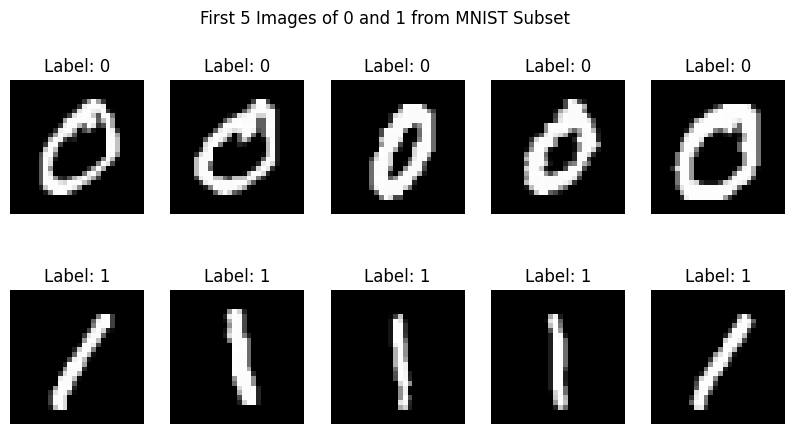

In [6]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

# 3. Initialize Weights and Bias:
We initialize the weights and bias to zero. This will be used to make predictions for each input.

In [7]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Answer the Following Question:
1. Question - 3: What does the weights array represent in this context?
2. Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

The weights array represents the importance of each input feature (pixel) in making the prediction.
Each weight corresponds to one pixel in the image.
Since there are 784 pixels, there are 784 weights.
The weights determine how much each pixel contributes to the final output of the perceptron.
Thus, the weights help the model decide whether an image belongs to class 0 or 1.

The weights are initialized to zero for simplicity and consistency at the start of training.
It provides a neutral starting point where all features are treated equally.
During training, the perceptron updates the weights based on errors and learns the correct values.
Effect on training:
*   The model will gradually adjust the weights through iterations (epochs).
*   For the perceptron algorithm, initializing weights to zero does not cause major issues because weights are updated differently for each input.
*   However, in more complex models, zero initialization can sometimes slow down learning or prevent proper learning.

# 4. Implement a Decision Function or Activation Function:
Assuming we have already learn the weights we will implement a step function which serves as an
decision function for perceptron.

In [8]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Input data (n_samples, n_features)
    - weights: Learned weights
    - bias: Learned bias

    Returns:
    - y_pred_all: Predicted labels (0 or 1)
    """

    # Linear combination
    predictions = np.dot(X, weights) + bias

    # Activation function (step function)
    y_pred_all = []

    for value in predictions:
        if value >= 0:
            y_pred_all.append(1)
        else:
            y_pred_all.append(0)

    return np.array(y_pred_all)

# 5. Implement the Perceptron Learning Algorithm:
Now, we will implement the main function train perceptron of the Perceptron algorithm. The algorithm will iterate over the dataset, compute the output, and update the weights and bias if the prediction isincorrect.

In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """

    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            # Step 1: Compute linear output
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step activation function
            if output >= 0:
                y_pred = 1
            else:
                y_pred = 0

            # Step 3: Update weights and bias if prediction is wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct_predictions += 1

        # Optional: print progress
        # print(f"Epoch {epoch+1}, Correct Predictions: {correct_predictions}")

    # Calculate final accuracy
    accuracy = correct_predictions / len(X)

    return weights, bias, accuracy

Answer the Following Question:
1. Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?
2. Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?
3. Question - 7:Why is the final accuracy important, and what do you expect it to be?

This line computes the linear combination of inputs and weights.
It multiplies each feature (pixel) by its corresponding weight and sums them.
Then, the bias is added to this sum.
Mathematically:
z=X[i]⋅weights+bias
This value (z) is used to decide the predicted class after applying the activation (step) function.

When the prediction is incorrect, the perceptron updates the weights and bias to reduce the error.
If the prediction is wrong:
weights=weights+learning_rate×(y[i]−y
bias=bias+learning_rate×(y[i]−y
This update helps the model move towards the correct classification.
If the prediction is correct, no update is made.

The final accuracy measures how well the perceptron model performs on the dataset.
*   It shows the proportion of correctly classified samples.
*   Higher accuracy indicates better model performance.
Expectation:
*   Since digits 0 and 1 are linearly separable, the perceptron should achieve very high accuracy, often close to 100% after sufficient training.

# 6. Putting it all Together:
Train the perceptron algorithm on whole dataset:

In [10]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


# 7. Visualizing the Misclassified Image:
Finally, let’s visualize the images where the model made incorrect predictions. If all images were correctly
classified, print a message indicating this.

In [11]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Answer the Following Question:
1. Question - 8:What does misclassified idx store, and how is it used in this code?
2. Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

The variable misclassified_idx stores the indices of all data points where the model made incorrect predictions.
It is obtained using:
np.where(y_pred != y)[0]
This means it finds all positions where the predicted label (y_pred) is not equal to the true label (y).
Usage in the code:
These indices are used to select and display the misclassified images.
The code visualizes up to 10 such images to help analyze where the model made mistakes.

If the output is “All images were correctly classified!”, it means:
The model has achieved 100% accuracy on the dataset.
There are no misclassified samples.
The perceptron has successfully learned to distinguish between the digits 0 and 1.
Interpretation:
This is expected because digits 0 and 1 are linearly separable.
It indicates that the model has performed very well on the given data.

**4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.**

# 1. Objective:
In this exercise, you will implement a Perceptron learning algorithm for binary classification using the MNIST dataset. Specifically, you will classify the digits 3 and 5. After completing the Perceptron algorithm, you will evaluate the model’s performance and visualize misclassified images.
Dataset: mnist_3_and_5.csv

4.5 To - Do:
1. Implement each Step as we implemented above.
2. Visualize the final misclassified images and Provide your conclusion.

1. Load Dataset

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_3_5 = pd.read_csv("mnist_3_and_5.csv")

# Features and labels
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


2. Convert Labels

In [13]:
# Convert labels: 3 → 0, 5 → 1
y = np.where(y == 3, 0, 1)

3. Visualize Dataset

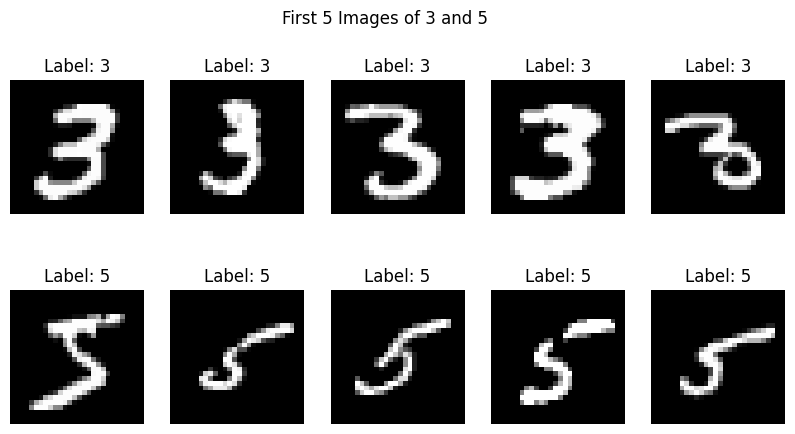

In [14]:
images_3 = X[y == 0]
images_5 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

4. Initialize Weights and Bias

In [15]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

5. Decision Function

In [16]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias

    y_pred_all = []
    for value in predictions:
        if value >= 0:
            y_pred_all.append(1)
        else:
            y_pred_all.append(0)

    return np.array(y_pred_all)

6. Train Perceptron

In [17]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias

            if output >= 0:
                y_pred = 1
            else:
                y_pred = 0

            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct_predictions += 1

    accuracy = correct_predictions / len(X)
    return weights, bias, accuracy

7. Train Model

In [18]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("The Final Accuracy is:", accuracy)

The Final Accuracy is: 0.9857716161984678


8. Visualize Misclassified Images

Final Accuracy: 0.9869
Correctly Classified: 2705/2741


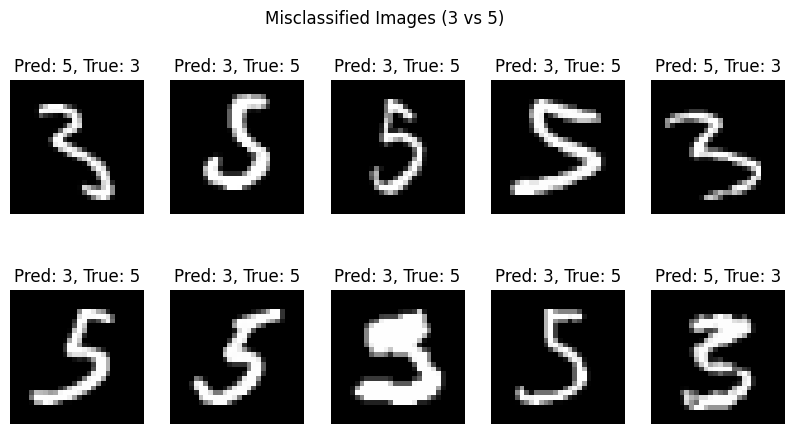

In [21]:
# Predictions
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Accuracy
final_accuracy = np.mean(y_pred == y)
correct_count = np.sum(y_pred == y)

print(f"Final Accuracy: {final_accuracy:.4f}")
print(f"Correctly Classified: {correct_count}/{len(y)}")

# Misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):

        # Convert back to original labels
        pred_label = 3 if y_pred[idx] == 0 else 5
        true_label = 3 if y[idx] == 0 else 5

        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")

After completing the Perceptron algorithm, the model’s performance was evaluated using accuracy. The results show that the perceptron is able to correctly classify many of the input images, but not all of them.
To further analyze the model’s performance, the misclassified images were visualized. These images help us understand where the model makes mistakes. It was observed that some digits, especially 3 and 5, appear visually similar, which makes them harder to distinguish.
This demonstrates that the perceptron model has limitations when dealing with data that is not linearly separable. Therefore, while the perceptron performs reasonably well, it may not achieve perfect accuracy for more complex classification tasks like distinguishing between 3 and 5.